In [2]:
%pip install yfinance pandas numpy statsmodels matplotlib

  Using cached yfinance-1.7.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached pandas-3.0.6-cp314-cp314-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached numpy-2.5.3-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached statsmodels-0.15.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.6 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (80 kB)
  Using cached curl_cffi-0.16.3-cp310-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (17 kB)
  Using cached lxml-6.1.3-cp314-cp314-manylinux_2_26_x86_64.manylinux_2_28_x86_64.whl.metadata (3.3 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.5.2-py3-none-any.whl.metadata (10 kB)
  Using cached protobuf-7.36.2-cp310-abi3-manylinux2014_x86_64.whl.metadata (595 bytes)
  Using cached pytz-2026.4-py2.py3-none-any.whl.metadata (22 kB)
  Using 

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
ko = yf.download("KO", start="2015-01-01", end="2025-01-01", auto_adjust=True)
ko.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,KO,KO,KO,KO,KO
Date,,,,,
2015-01-02,29.215933,29.396194,28.980209,29.299129,9921100
2015-01-05,29.215933,29.791378,29.174336,29.597251,26292600
2015-01-06,29.437788,29.770575,29.285262,29.403123,16897500
2015-01-07,29.805244,29.888440,29.520989,29.673515,13412300
2015-01-08,30.165749,30.207348,29.881493,29.936959,21743600


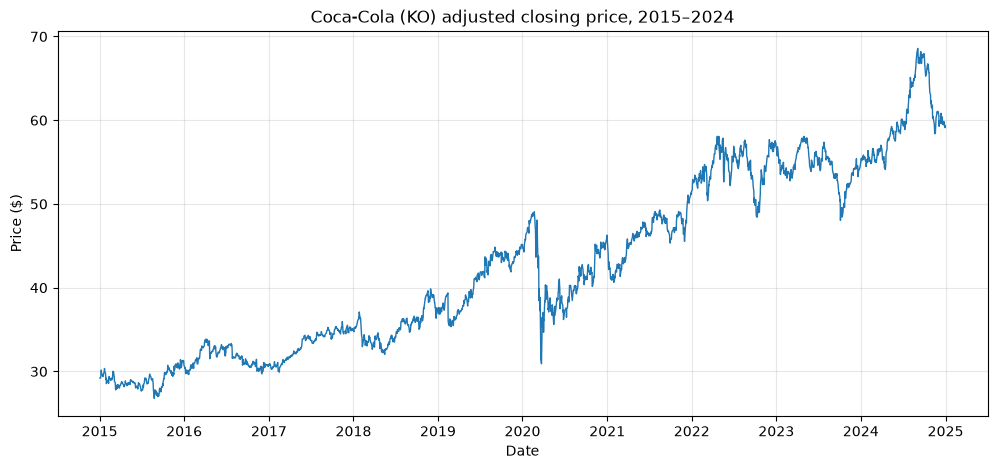

In [4]:
close = ko["Close"]["KO"]   # pick the Close column for KO, as a single series

plt.figure(figsize=(12, 5))
plt.plot(close.index, close, linewidth=1)
plt.title("Coca-Cola (KO) adjusted closing price, 2015–2024")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.grid(alpha=0.3)
plt.show()

[*********************100%***********************]  2 of 2 completed


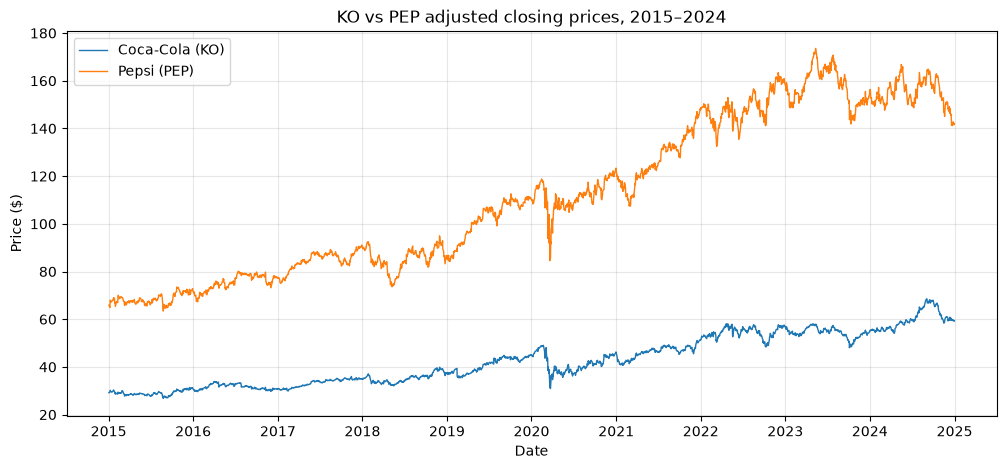

In [6]:
prices = yf.download(["KO", "PEP"], start="2015-01-01", end="2025-01-01",
                     auto_adjust=True)["Close"]

plt.figure(figsize=(12, 5))
plt.plot(prices.index, prices["KO"], label="Coca-Cola (KO)", linewidth=1)
plt.plot(prices.index, prices["PEP"], label="Pepsi (PEP)", linewidth=1)
plt.title("KO vs PEP adjusted closing prices, 2015–2024")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Instead of plotting just the two stock prices over time, let's see how much they grow in comparison to Jan 1st 2015:

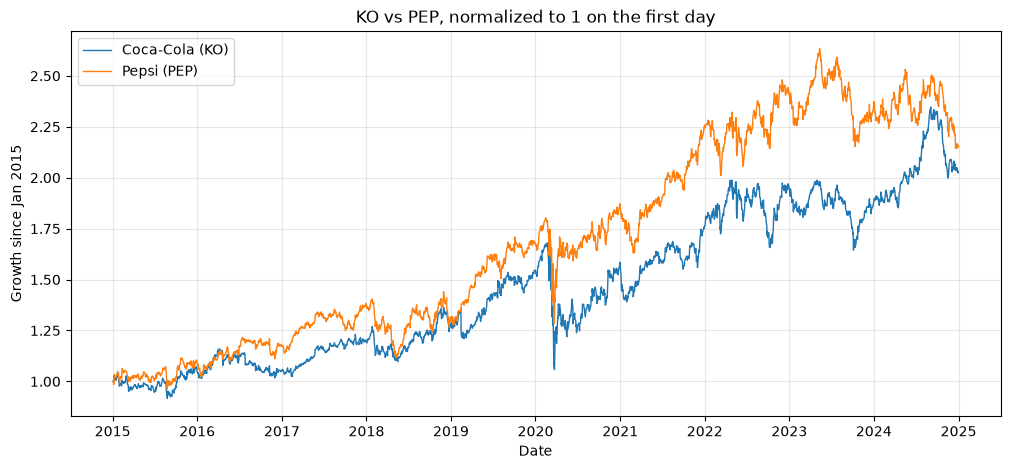

In [7]:
normalized = prices / prices.iloc[0]   # divide every price by the first day's price

plt.figure(figsize=(12, 5))
plt.plot(normalized.index, normalized["KO"], label="Coca-Cola (KO)", linewidth=1)
plt.plot(normalized.index, normalized["PEP"], label="Pepsi (PEP)", linewidth=1)
plt.title("KO vs PEP, normalized to 1 on the first day")
plt.xlabel("Date")
plt.ylabel("Growth since Jan 2015")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 1st cointegration test: KO and PEP (Coca-Cola and Pepsi)

In [8]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint # Engle-Grainger cointegration test

Load the data and take logs:

In [9]:
x = np.log(prices["KO"])   # x_t = log price of KO
y = np.log(prices["PEP"])  # y_t = log price of PEP

We now regress to find $\beta$ and $\mu$ in:

$$
s_t \text{ (spread)} = x - \hat{\beta}y - \hat{\mu}
$$

In [12]:
Y = sm.add_constant(y)        # predictor table: a column of 1s plus PEP
model = sm.OLS(x, Y).fit()    # regress x (KO) on y (PEP)

mu_hat = model.params["const"]
beta_hat = model.params["PEP"]
print(f"mu_hat   = {mu_hat:.4f}")
print(f"beta_hat = {beta_hat:.4f}")

spread = x - beta_hat * y - mu_hat   # s_t = x_t - beta*y_t - mu

mu_hat   = -0.0389
beta_hat = 0.8053


Let's visualize the spread. For two cointegrated time series, the spread should be crossing the 0-line often and not stray too far for long periods of time. A spread that drifts away for years at a time is mroe indicative of a random walk.

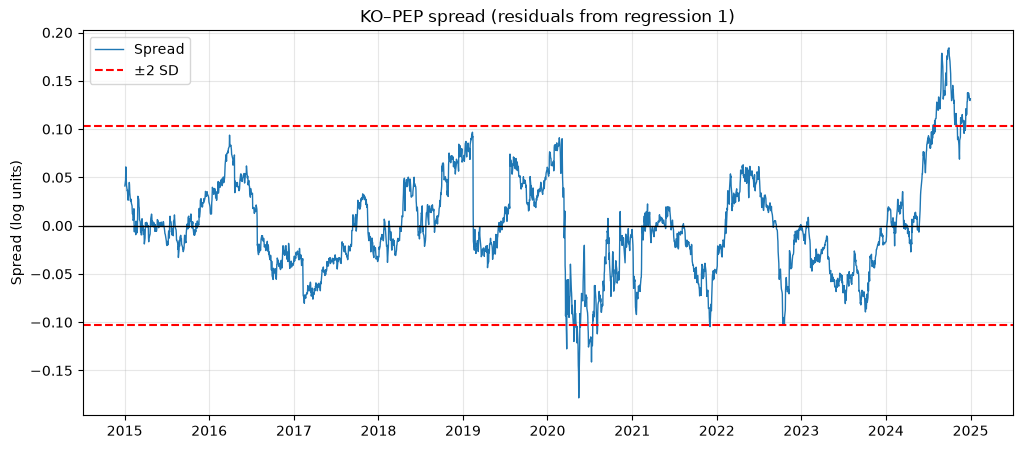

In [13]:
sd = spread.std()

plt.figure(figsize=(12, 5))
plt.plot(spread.index, spread, linewidth=1, label="Spread")
plt.axhline(0, color="black", linewidth=1)                       # the mean
plt.axhline(2 * sd, color="red", linestyle="--", label="±2 SD")  # entry bands
plt.axhline(-2 * sd, color="red", linestyle="--")
plt.title("KO–PEP spread (residuals from regression 1)")
plt.ylabel("Spread (log units)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Nice! The spread crosses the 0-line several times and rarely leaves the +- 0.10 band. Let's clarify what this shows a little better:

The spread is in **log units**. Given PEP's price on a given day, regression 1 (which we just did) predicts a log price for KO:

$$
\log P_t ^{\text{KO, pred}} = 
$$
